In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
data = load_breast_cancer()
X = data.data          # shape: (569, 30)
y = data.target

print (X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

(569, 30) (569,)


In [3]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
import os
sys.path.append(os.path.abspath(".."))
from core.myTensor import MyTensor
from nn.sequential import Sequential
from nn.linear import Linear
from nn.activations import Tanh, Sigmoid
from loss.BCELoss import BCELoss
from optim.sgd import SGD
from optim.adam import Adam

In [5]:
def convert_to_myTensor(X, y):
    X_batch = []
    y_batch = []
    for sample, y in zip(X, y):
        batch_sample = [MyTensor(feature) for feature in sample]
        X_batch.append(batch_sample)
        y_batch.append(MyTensor(float(y)))
    return X_batch, y_batch
    

In [6]:
X_train, y_train = convert_to_myTensor(X_train, y_train)
X_test, y_test = convert_to_myTensor(X_test, y_test)
print (X.shape, y.shape)

(569, 30) (569,)


In [7]:
print (X_train[0])
print (y_train[0])

[MyTensor(data=-1.4407529621170239, require_grad =False, grad=0.0), MyTensor(data=-0.435319469935582, require_grad =False, grad=0.0), MyTensor(data=-1.3620849677475046, require_grad =False, grad=0.0), MyTensor(data=-1.139117896666204, require_grad =False, grad=0.0), MyTensor(data=0.7805733144944469, require_grad =False, grad=0.0), MyTensor(data=0.7189212819653806, require_grad =False, grad=0.0), MyTensor(data=2.823134514135953, require_grad =False, grad=0.0), MyTensor(data=-0.11914956451814888, require_grad =False, grad=0.0), MyTensor(data=1.0926621933891103, require_grad =False, grad=0.0), MyTensor(data=2.4581726094723977, require_grad =False, grad=0.0), MyTensor(data=-0.26380039208863315, require_grad =False, grad=0.0), MyTensor(data=-0.016052455483316047, require_grad =False, grad=0.0), MyTensor(data=-0.4704135720595107, require_grad =False, grad=0.0), MyTensor(data=-0.4747608837338361, require_grad =False, grad=0.0), MyTensor(data=0.8383649314058171, require_grad =False, grad=0.0),

In [8]:
loss = BCELoss()

In [9]:
def batchify(X, Y, batch_size):
    for i in range(0, len(X), batch_size):
        yield X[i:i+batch_size], Y[i:i+batch_size]

In [10]:
def train(model, optimizer, loss_fn, X_train_t, y_train_t, epochs=50, batch_size=32):
    losses = []
    for epoch in range(epochs):
        total_loss = 0
        for X_batch, y_batch in batchify(X_train_t, y_train_t, batch_size):
            optimizer.zero_grad()
            y_preds = []
            for X_sample in X_batch:
                y_pred = model(X_sample)
                y_preds.append(y_pred)
            current_loss = loss(y_preds, y_batch)
            current_loss.backward()
            optimizer.step()
            total_loss += current_loss.data * len(y_batch)
    
        epoch_loss = total_loss / len(y_train_t)
        losses.append(epoch_loss)
        print(f"Epoch {epoch:02d} | Loss: {epoch_loss:.4f}")
    return losses

In [11]:
def accuracy(model, X, Y):
    correct = 0
    for x, y in zip(X, Y):
        pred = model(x).data
        pred_label = 1 if pred > 0.5 else 0
        if pred_label == int(y.data):
            correct += 1
    return correct / len(X)

In [13]:
model_sgd = Sequential(
    Linear(len(X_train[0]), 32),
    Tanh(),
    Linear(32, 16),
    Tanh(),
    Linear(16, 1),
    Sigmoid(),
)
sgd = SGD(model_sgd.parameters(), lr=0.01)
sgd_losses = train(model_sgd, sgd, loss, X_train, y_train)
train_acc_sgd = accuracy(model_sgd, X_train, y_train)
test_acc_sgd = accuracy(model_sgd, X_test, y_test)
print("Train accuracy:", train_acc_sgd)
print("Test accuracy:", test_acc_sgd)

Epoch 00 | Loss: 0.7279
Epoch 01 | Loss: 0.5705
Epoch 02 | Loss: 0.4790
Epoch 03 | Loss: 0.4206
Epoch 04 | Loss: 0.3793
Epoch 05 | Loss: 0.3483
Epoch 06 | Loss: 0.3237
Epoch 07 | Loss: 0.3036
Epoch 08 | Loss: 0.2865
Epoch 09 | Loss: 0.2716
Epoch 10 | Loss: 0.2584
Epoch 11 | Loss: 0.2467
Epoch 12 | Loss: 0.2362
Epoch 13 | Loss: 0.2267
Epoch 14 | Loss: 0.2182
Epoch 15 | Loss: 0.2104
Epoch 16 | Loss: 0.2032
Epoch 17 | Loss: 0.1967
Epoch 18 | Loss: 0.1908
Epoch 19 | Loss: 0.1853
Epoch 20 | Loss: 0.1802
Epoch 21 | Loss: 0.1755
Epoch 22 | Loss: 0.1711
Epoch 23 | Loss: 0.1669
Epoch 24 | Loss: 0.1630
Epoch 25 | Loss: 0.1594
Epoch 26 | Loss: 0.1559
Epoch 27 | Loss: 0.1527
Epoch 28 | Loss: 0.1496
Epoch 29 | Loss: 0.1467
Epoch 30 | Loss: 0.1439
Epoch 31 | Loss: 0.1413
Epoch 32 | Loss: 0.1388
Epoch 33 | Loss: 0.1364
Epoch 34 | Loss: 0.1341
Epoch 35 | Loss: 0.1320
Epoch 36 | Loss: 0.1299
Epoch 37 | Loss: 0.1279
Epoch 38 | Loss: 0.1260
Epoch 39 | Loss: 0.1242
Epoch 40 | Loss: 0.1225
Epoch 41 | Loss:

In [20]:
model_adam = Sequential(
    Linear(len(X_train[0]), 16),
    Tanh(),
    Linear(16, 1),
    Sigmoid(),
)
adam = Adam(model_adam.parameters(), lr=0.001)
adam_losses = train(model_adam, adam, loss, X_train, y_train)
train_acc_adam = accuracy(model_adam, X_train, y_train)
test_acc_dam = accuracy(model_adam, X_test, y_test)
print("Train accuracy:", train_acc_adam)
print("Test accuracy:", test_acc_dam)

Epoch 00 | Loss: 1.1541
Epoch 01 | Loss: 0.8698
Epoch 02 | Loss: 0.6385
Epoch 03 | Loss: 0.4670
Epoch 04 | Loss: 0.3508
Epoch 05 | Loss: 0.2751
Epoch 06 | Loss: 0.2262
Epoch 07 | Loss: 0.1936
Epoch 08 | Loss: 0.1708
Epoch 09 | Loss: 0.1544
Epoch 10 | Loss: 0.1419
Epoch 11 | Loss: 0.1322
Epoch 12 | Loss: 0.1244
Epoch 13 | Loss: 0.1180
Epoch 14 | Loss: 0.1125
Epoch 15 | Loss: 0.1078
Epoch 16 | Loss: 0.1037
Epoch 17 | Loss: 0.1000
Epoch 18 | Loss: 0.0968
Epoch 19 | Loss: 0.0940
Epoch 20 | Loss: 0.0914
Epoch 21 | Loss: 0.0891
Epoch 22 | Loss: 0.0869
Epoch 23 | Loss: 0.0850
Epoch 24 | Loss: 0.0833
Epoch 25 | Loss: 0.0817
Epoch 26 | Loss: 0.0802
Epoch 27 | Loss: 0.0789
Epoch 28 | Loss: 0.0777
Epoch 29 | Loss: 0.0766
Epoch 30 | Loss: 0.0755
Epoch 31 | Loss: 0.0745
Epoch 32 | Loss: 0.0736
Epoch 33 | Loss: 0.0727
Epoch 34 | Loss: 0.0718
Epoch 35 | Loss: 0.0710
Epoch 36 | Loss: 0.0702
Epoch 37 | Loss: 0.0694
Epoch 38 | Loss: 0.0687
Epoch 39 | Loss: 0.0680
Epoch 40 | Loss: 0.0673
Epoch 41 | Loss:

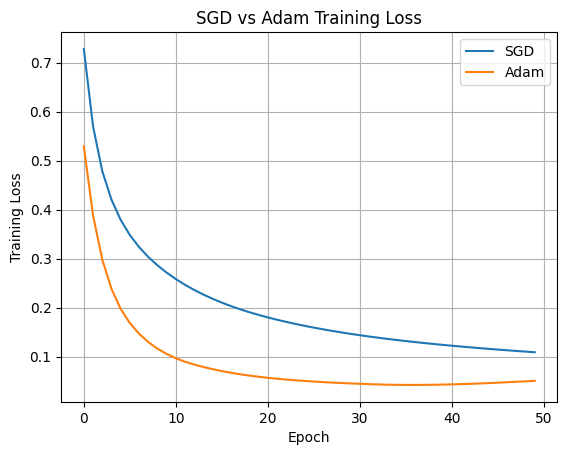

In [19]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(sgd_losses, label="SGD")
plt.plot(adam_losses, label="Adam")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("SGD vs Adam Training Loss")
plt.legend()
plt.grid(True)

plt.show()
